# DuckLake vs Iceberg: pruning & metadata footprint

Both backends store the **same open Parquet** in the **same L3s layout**, queried through **DuckDB**;
only the table-format / catalog layer differs (Apache **Iceberg** vs **DuckLake**). We compare the two
*format-intrinsic* axes:

1. **Pruning**, how much data each format skips for a query (bytes read after pruning).
2. **Metadata footprint**, how much metadata the format keeps.

> Planning latency and concurrency are **not compared**: they depend on the number of files and on the
> catalog deployment, i.e. tunable setup choices, not intrinsic properties of the format.

Reads the result CSVs under `results/`. No network needed.

In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import os

ICE = '#065A82'   # Iceberg
DL  = '#E07A5F'   # DuckLake
MID = '#21295C'
plt.rcParams.update({'font.size': 12, 'axes.spines.top': False, 'axes.spines.right': False,
                     'figure.facecolor': 'white'})
R = 'results/'
fmt   = pd.read_csv(R + 'format_compare.csv')
props = pd.read_csv(R + 'tab_catalog_properties.csv')

# keep only Iceberg and DuckLake-on-DuckDB, relabel to plain names
meta = props[props['backend'].isin(['Iceberg REST', 'DuckLake (file)'])].copy()
meta['label'] = meta['backend'].map({'Iceberg REST': 'Iceberg', 'DuckLake (file)': 'DuckLake'})
meta = meta.set_index('label').loc[['Iceberg', 'DuckLake']]
os.makedirs('figs', exist_ok=True)
meta[['metadata_MB']]

,metadata_MB
label,
Iceberg,0.54
DuckLake,4.99


## 1. Pruning: equivalent bytes skipped
Same open Parquet, same layout: both formats prune to essentially the same bytes at every selectivity.
Left: bytes read per query (day window). Right: candidate share (bytes read as % of the 3.8 GB table)
across the hour / day / week windows.

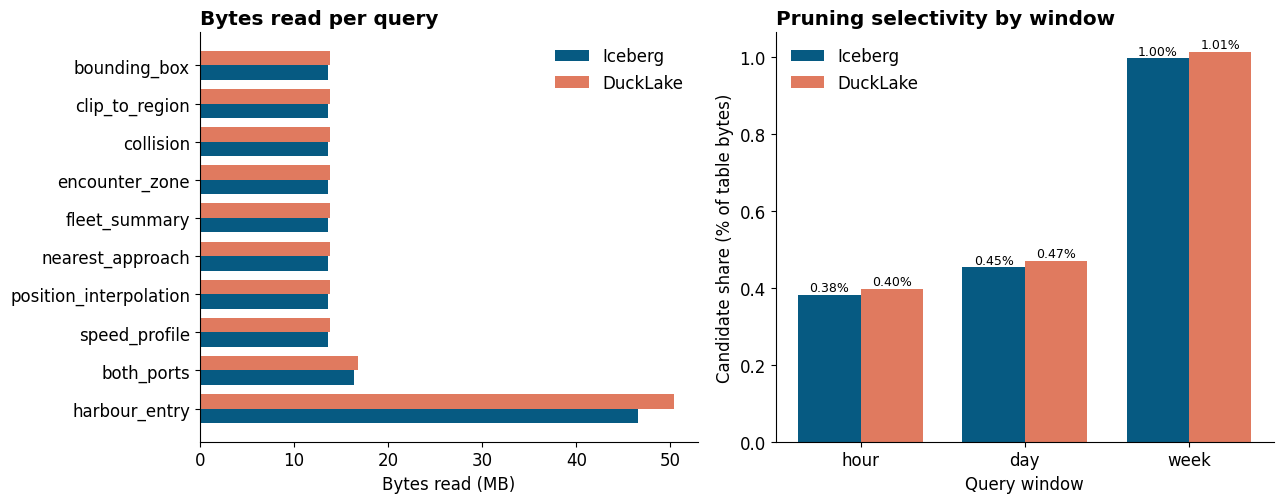

In [3]:
d = fmt[fmt['selectivity'] == 'day'].copy()
d['backend'] = d['backend'].str.replace('_L3s', '', regex=False)
by = d.pivot(index='query', columns='backend', values='bytes_read') / 1e6  # MB
order = by.mean(axis=1).sort_values().index
by = by.loc[order]

fmt2 = fmt.copy(); fmt2['backend'] = fmt2['backend'].str.replace('_L3s', '', regex=False)
share = fmt2.groupby(['selectivity', 'backend'])['bytes_pct'].mean().unstack().reindex(['hour', 'day', 'week'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2))
y = np.arange(len(order)); h = 0.38
ax1.barh(y + h/2, by['iceberg'],  h, color=ICE, label='Iceberg')
ax1.barh(y - h/2, by['ducklake'], h, color=DL,  label='DuckLake')
ax1.set_yticks(y); ax1.set_yticklabels(order); ax1.invert_yaxis()
ax1.set_xlabel('Bytes read (MB)')
ax1.set_title('Bytes read per query', fontweight='bold', loc='left')
ax1.legend(frameon=False, loc='upper right')

x = np.arange(len(share)); w = 0.38
ax2.bar(x - w/2, share['iceberg'],  w, color=ICE, label='Iceberg')
ax2.bar(x + w/2, share['ducklake'], w, color=DL,  label='DuckLake')
for i, win in enumerate(share.index):
    ax2.text(i - w/2, share['iceberg'][win]+0.01,  f"{share['iceberg'][win]:.2f}%",  ha='center', fontsize=9)
    ax2.text(i + w/2, share['ducklake'][win]+0.01, f"{share['ducklake'][win]:.2f}%", ha='center', fontsize=9)
ax2.set_xticks(x); ax2.set_xticklabels(share.index)
ax2.set_xlabel('Query window'); ax2.set_ylabel('Candidate share (% of table bytes)')
ax2.set_title('Pruning selectivity by window', fontweight='bold', loc='left')
ax2.legend(frameon=False)
fig.tight_layout(); fig.savefig('figs/dl_vs_ice_pruning.png', dpi=200, bbox_inches='tight'); plt.show()

## 2. Metadata footprint
The formats diverge on how much metadata they keep: Iceberg's manifest metadata is far smaller than
DuckLake's catalog.

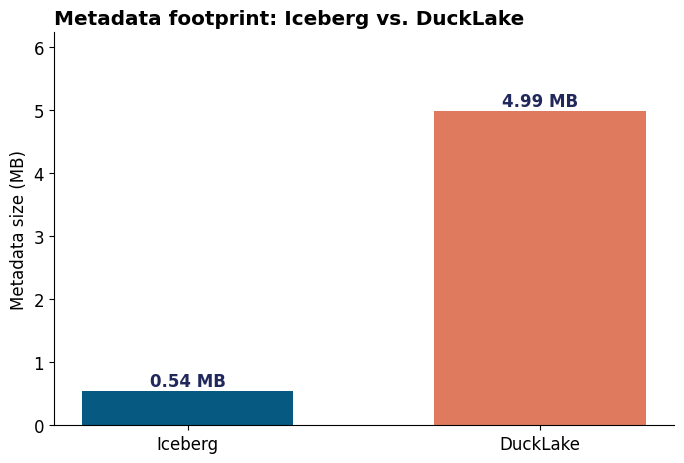

In [4]:
labels = meta.index.tolist()            # ['Iceberg', 'DuckLake']
vals   = meta['metadata_MB'].tolist()
fig, ax = plt.subplots(figsize=(7, 4.8))
bars = ax.bar(labels, vals, color=[ICE, DL], width=0.6)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.08, f'{v:.2f} MB', ha='center', fontweight='bold', color=MID)
ax.set_ylabel('Metadata size (MB)')
factor = vals[1] / vals[0]
ax.set_title(f'Metadata footprint: Iceberg vs. DuckLake', fontweight='bold', loc='left')
ax.set_ylim(0, max(vals)*1.25)
fig.tight_layout(); fig.savefig('figs/dl_vs_ice_metadata.png', dpi=200, bbox_inches='tight'); plt.show()

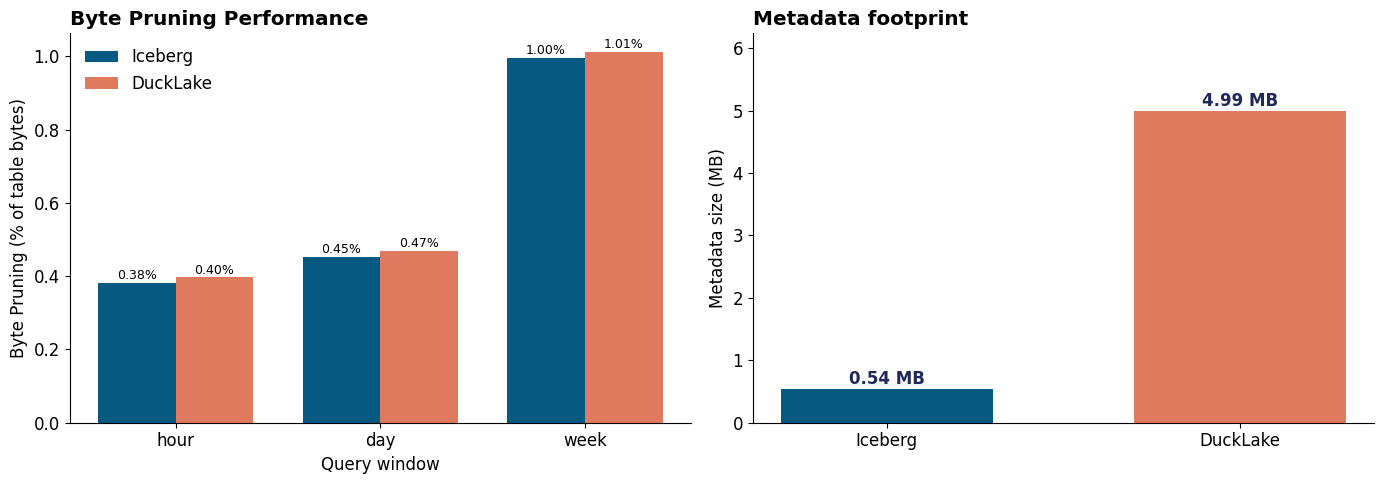

In [6]:
fmt2 = fmt.copy()
fmt2['backend'] = fmt2['backend'].str.replace('_L3s', '', regex=False)
share = fmt2.groupby(['selectivity', 'backend'])['bytes_pct'].mean().unstack().reindex(['hour', 'day', 'week'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(share))
w = 0.38
ax1.bar(x - w/2, share['iceberg'], w, color=ICE, label='Iceberg')
ax1.bar(x + w/2, share['ducklake'], w, color=DL, label='DuckLake')
for i, win in enumerate(share.index):
    ax1.text(i - w/2, share.at[win, 'iceberg'] + 0.01, f"{share.at[win, 'iceberg']:.2f}%", ha='center', fontsize=9)
    ax1.text(i + w/2, share.at[win, 'ducklake'] + 0.01, f"{share.at[win, 'ducklake']:.2f}%", ha='center', fontsize=9)
ax1.set_xticks(x)
ax1.set_xticklabels(share.index)
ax1.set_xlabel('Query window')
ax1.set_ylabel('Byte Pruning (% of table bytes)')
ax1.set_title('Byte Pruning Performance', fontweight='bold', loc='left')
ax1.legend(frameon=False)

labels = meta.index.tolist()
vals = meta['metadata_MB'].tolist()
bars = ax2.bar(labels, vals, color=[ICE, DL], width=0.6)
for b, v in zip(bars, vals):
    ax2.text(b.get_x() + b.get_width() / 2, v + 0.08, f'{v:.2f} MB', ha='center', fontweight='bold', color=MID)
ax2.set_ylabel('Metadata size (MB)')
ax2.set_title('Metadata footprint', fontweight='bold', loc='left')
ax2.set_ylim(0, max(vals) * 1.25)

fig.tight_layout()
fig.savefig('figs/dl_vs_ice_combined.png', dpi=200, bbox_inches='tight')
plt.show()